# Final Results: Checkpoint-Only Evaluation under Random vs Multilabel-Stratified 5-Fold CV

This notebook mirrors `PostTraining_Final_Results.ipynb`, but does **not** train the model in-notebook.
Instead, it loads a fixed trained checkpoint and runs the same reporting pipeline:
- random and multilabel iterative-stratified 5-fold CV splitting
- fold-level metric tables
- pooled OOF ROC and PR curves


## 1. Import Necessary Modules and Libraries

In [1]:
import warnings

warnings.filterwarnings("ignore")

from dataclasses import dataclass
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.model_selection import KFold, train_test_split

try:
    from IPython.display import display
except Exception:

    def display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)


try:
    from skmultilearn.model_selection import (
        IterativeStratification,
        iterative_train_test_split,
    )
except ModuleNotFoundError as exc:
    raise ImportError(
        "scikit-multilearn is required for the multilabel iterative stratified evaluation in this notebook. "
        "Install it with `python -m pip install scikit-multilearn` or sync the project environment."
    ) from exc

## 2. Configuration and Fixed Final-Model Settings


In [2]:
# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# --- Final proposed model recipe ---
BATCH_SIZE = 128
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
MAX_GRAD_NORM = 5.0
WEIGHT_DECAY = 1e-4
HEAD_LR = 1e-4
DROPOUT = 0.1
FOCAL_GAMMA = 4.0

RUN_SMOKE = False
SMOKE_FOLDS = 2
SMOKE_EPOCHS = 1
RUN_FULL = True
FORCE_CPU = False
SAVE_FOLD_CHECKPOINTS = False

# --- Data and checkpoint paths ---
DATA_ROOT = Path("data")
TRAIN_CSV = DATA_ROOT / "Train" / "tox21_train_clean.csv"
VAL_CSV = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TEST_CSV = DATA_ROOT / "Test" / "tox21_test_clean.csv"
CHECKPOINT_PATH = Path(
    "/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase2_adaptive_best.pt"
)
for path in [TRAIN_CSV, VAL_CSV, TEST_CSV, CHECKPOINT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

# --- Fold strategies ---
N_FOLDS = 5
STRATEGY_ORDER = ["random", "multilabel_iterstrat"]
STRATEGY_LABELS = {
    "random": "Random 5-Fold CV",
    "multilabel_iterstrat": "Multilabel Iterative Stratified 5-Fold CV",
}
GLOBAL_METRICS = ["macro_auroc", "macro_auprc", "micro_auroc", "micro_auprc"]
PER_TASK_METRICS = ["AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]

FIXED_POSTTRAIN_PARAMS = {
    "checkpoint_path": str(CHECKPOINT_PATH),
    "finetuning_scope": "pred_head only",
    "loss_name": "focal",
    "focal_gamma": FOCAL_GAMMA,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": EARLY_STOPPING_PATIENCE,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "training_in_notebook": False,
}

TOX21_TASKS = [
    "NR-AR",
    "NR-AR-LBD",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER",
    "NR-ER-LBD",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

device = (
    torch.device("cpu")
    if FORCE_CPU
    else torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available() else "cpu"
    )
)

print("Device:", device)
print("Torch version:", torch.__version__)
print("SELFIES version:", sf.__version__)
print("RUN_FULL:", RUN_FULL, "| RUN_SMOKE:", RUN_SMOKE)
print("Checkpoint-only evaluation recipe:")
print(FIXED_POSTTRAIN_PARAMS)

Device: mps
Torch version: 2.10.0
SELFIES version: 2.1.1
RUN_FULL: True | RUN_SMOKE: False
Checkpoint-only evaluation recipe:
{'checkpoint_path': '/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase2_adaptive_best.pt', 'finetuning_scope': 'pred_head only', 'loss_name': 'focal', 'focal_gamma': 4.0, 'batch_size': 128, 'max_epochs': 50, 'patience': 8, 'head_lr': 0.0001, 'weight_decay': 0.0001, 'training_in_notebook': False}


## 3. Load the Tox21 Data, Checkpoint Metadata, and Build the Sequence Dataset

In [3]:
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
print("checkpoint keys:", sorted(ckpt.keys()))

TOKEN_TO_IDX = ckpt["token_to_idx"]
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}
PAD_IDX = ckpt["pad_idx"]
UNK_IDX = ckpt["unk_idx"]
EOS_IDX = ckpt["eos_idx"]
MAX_LEN = int(ckpt["max_len"])
SEQ_LEN = int(ckpt["seq_len"])
VOCAB_SIZE = int(ckpt["vocab_size"])
LATENT_DIM = int(ckpt["model_state_dict"]["fc_mu.weight"].shape[0])
NUM_TASKS = int(ckpt["model_state_dict"]["pred_head.9.bias"].shape[0])

if NUM_TASKS != len(TOX21_TASKS):
    raise ValueError(
        f"Checkpoint head expects {NUM_TASKS} tasks, but TOX21_TASKS has {len(TOX21_TASKS)} entries."
    )

print(
    f"SEQ_LEN={SEQ_LEN}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, LATENT_DIM={LATENT_DIM}, NUM_TASKS={NUM_TASKS}"
)


def load_tox21_frame(path: Path, origin_split: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")

    missing_tasks = [task for task in TOX21_TASKS if task not in df.columns]
    if missing_tasks:
        raise ValueError(f"{path} missing tasks: {missing_tasks}")

    df = df.dropna(subset=["canonical_smiles"]).reset_index(drop=True).copy()
    df["canonical_smiles"] = df["canonical_smiles"].astype(str)
    df[TOX21_TASKS] = df[TOX21_TASKS].apply(pd.to_numeric, errors="coerce")
    df["origin_split"] = origin_split
    return df


def encode_selfies(sf_str: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in sf.split_selfies(sf_str)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def build_aligned_dataset(df: pd.DataFrame, dataset_name: str) -> dict:
    ids_rows = []
    y_rows = []
    mask_rows = []
    meta_rows = []
    dropped_encoding = 0
    dropped_length = 0
    dropped_missing = 0

    for _, row in df.iterrows():
        smiles = row["canonical_smiles"]

        try:
            sf_str = sf.encoder(smiles)
        except Exception:
            dropped_encoding += 1
            continue

        tokens = list(sf.split_selfies(sf_str))
        if len(tokens) > MAX_LEN:
            dropped_length += 1
            continue

        labels = row[TOX21_TASKS].to_numpy(dtype=np.float32)
        mask = ~np.isnan(labels)
        if mask.sum() == 0:
            dropped_missing += 1
            continue

        ids = encode_selfies(sf_str)
        labels = np.nan_to_num(labels, nan=0.0)

        ids_rows.append(ids)
        y_rows.append(labels)
        mask_rows.append(mask.astype(np.float32))
        meta_rows.append(
            {
                "canonical_smiles": smiles,
                "selfies": sf_str,
                "origin_split": row["origin_split"],
            }
        )

    if not ids_rows:
        raise RuntimeError(
            "No aligned samples left after SELFIES encoding and checkpoint-length filtering."
        )

    x = np.full((len(ids_rows), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, ids in enumerate(ids_rows):
        x[i, : len(ids)] = ids

    y = np.array(y_rows, dtype=np.float32)
    mask = np.array(mask_rows, dtype=np.float32)
    meta = pd.DataFrame(meta_rows).reset_index(drop=True)
    meta["aligned_idx"] = np.arange(len(meta))

    return {
        "name": dataset_name,
        "x": x,
        "y": y,
        "mask": mask,
        "meta": meta,
        "stats": {
            "input_rows": int(len(df)),
            "kept_rows": int(len(y)),
            "dropped_encoding": int(dropped_encoding),
            "dropped_length": int(dropped_length),
            "dropped_missing": int(dropped_missing),
        },
    }


train_df_raw = load_tox21_frame(TRAIN_CSV, "train")
val_df_raw = load_tox21_frame(VAL_CSV, "val")
test_df_raw = load_tox21_frame(TEST_CSV, "test")
all_df_raw = pd.concat([train_df_raw, val_df_raw, test_df_raw], ignore_index=True)

sequence_dataset = build_aligned_dataset(
    all_df_raw, dataset_name="tox21_sequence_ready"
)

origin_counts = sequence_dataset["meta"]["origin_split"].value_counts().to_dict()
orig_train_n = int(origin_counts.get("train", 0))
orig_val_n = int(origin_counts.get("val", 0))
orig_test_n = int(origin_counts.get("test", 0))

if min(orig_train_n, orig_val_n, orig_test_n) <= 0:
    raise ValueError(
        "Expected non-empty train/val/test origins after alignment filtering."
    )

INNER_VAL_FRACTION = orig_val_n / max(orig_train_n + orig_val_n, 1)

print("Sequence-ready dataset stats:")
print(sequence_dataset["stats"])
print(f"Aligned sequence tensor shape: {sequence_dataset['x'].shape}")
print(f"Aligned label matrix shape   : {sequence_dataset['y'].shape}")
print(f"Inner validation fraction used for fold diagnostics: {INNER_VAL_FRACTION:.4f}")

origin_summary_df = (
    sequence_dataset["meta"]["origin_split"]
    .value_counts()
    .rename_axis("origin_split")
    .reset_index(name="n_sequence_ready")
)

positive_rate_df = (
    pd.DataFrame(sequence_dataset["y"], columns=TOX21_TASKS)
    .mean()
    .to_frame("positive_rate")
    .T
)

display(origin_summary_df)
display(positive_rate_df)

checkpoint keys: ['best_epoch', 'best_val_token_acc', 'best_val_total', 'decoder_output', 'encoder_layout', 'eos_idx', 'epoch', 'epochs_no_improve', 'history', 'loss_name', 'max_len', 'model_state_dict', 'optimizer_state_dict', 'pad_idx', 'scheduler_state_dict', 'selection_metric', 'seq_len', 'test_metrics', 'token_to_idx', 'unk_idx', 'vocab_size']
SEQ_LEN=121, VOCAB_SIZE=198, MAX_LEN=120, LATENT_DIM=292, NUM_TASKS=12
Sequence-ready dataset stats:
{'input_rows': 7823, 'kept_rows': 7772, 'dropped_encoding': 0, 'dropped_length': 51, 'dropped_missing': 0}
Aligned sequence tensor shape: (7772, 121)
Aligned label matrix shape   : (7772, 12)
Inner validation fraction used for fold diagnostics: 0.1099


,origin_split,n_sequence_ready
0,train,6237
1,val,770
2,test,765


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
positive_rate,0.039115,0.030494,0.098688,0.038085,0.100875,0.044261,0.023546,0.120818,0.033582,0.047864,0.116701,0.052625


## 4. Cross-Validation Split Utilities and Reporting Helpers

In [4]:
def slice_dataset(dataset: dict, indices: np.ndarray, split_name: str) -> dict:
    indices = np.asarray(indices, dtype=np.int64)
    indices = np.sort(indices)
    return {
        "name": split_name,
        "x": dataset["x"][indices],
        "y": dataset["y"][indices],
        "mask": dataset["mask"][indices],
        "meta": dataset["meta"].iloc[indices].reset_index(drop=True),
    }


def _safe_mean(values) -> float:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.mean()) if len(vals) else np.nan


def _safe_std(values) -> float:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.std(ddof=1)) if len(vals) > 1 else np.nan


def _mean_task_positive_rate(y: np.ndarray, mask: np.ndarray) -> float:
    rates = []
    for j in range(y.shape[1]):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue
        rates.append(float(y[valid, j].mean()))
    return float(np.mean(rates)) if rates else np.nan


def _any_positive_rate(y: np.ndarray, mask: np.ndarray) -> float:
    valid = mask == 1
    if len(valid) == 0:
        return np.nan
    return float(((y == 1) & valid).any(axis=1).mean())


def _masked_arrays(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray):
    valid = mask.astype(bool)
    return y_true[valid].astype(int), y_probs[valid]


def _macro_auroc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    vals = []
    for j in range(y_true.shape[1]):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue
        yt = y_true[valid, j].astype(int)
        pt = y_probs[valid, j]
        if np.unique(yt).size < 2:
            continue
        vals.append(roc_auc_score(yt, pt))
    return float(np.mean(vals)) if vals else np.nan


def _macro_auprc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    vals = []
    for j in range(y_true.shape[1]):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue
        yt = y_true[valid, j].astype(int)
        pt = y_probs[valid, j]
        if np.unique(yt).size < 2:
            continue
        vals.append(average_precision_score(yt, pt))
    return float(np.mean(vals)) if vals else np.nan


def _micro_auroc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    yt, pt = _masked_arrays(y_true, y_probs, mask)
    if len(yt) == 0 or np.unique(yt).size < 2:
        return np.nan
    return float(roc_auc_score(yt, pt))


def _micro_auprc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    yt, pt = _masked_arrays(y_true, y_probs, mask)
    if len(yt) == 0 or np.unique(yt).size < 2:
        return np.nan
    return float(average_precision_score(yt, pt))


def compute_global_metrics(
    y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray
) -> dict:
    return {
        "macro_auroc": _macro_auroc(y_true, y_probs, mask),
        "macro_auprc": _macro_auprc(y_true, y_probs, mask),
        "micro_auroc": _micro_auroc(y_true, y_probs, mask),
        "micro_auprc": _micro_auprc(y_true, y_probs, mask),
    }


def _binary_metrics(
    y_true: np.ndarray, probs: np.ndarray, mask: np.ndarray, threshold: float = 0.5
) -> dict:
    valid = mask.astype(bool)
    y_true = y_true[valid].astype(int)
    probs = probs[valid]

    out = {
        "n": int(len(y_true)),
        "Accuracy": np.nan,
        "F1": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) == 0:
        return out

    y_hat = (probs >= threshold).astype(int)
    out["Accuracy"] = float(accuracy_score(y_true, y_hat))
    out["F1"] = float(f1_score(y_true, y_hat, zero_division=0))
    out["Precision"] = float(precision_score(y_true, y_hat, zero_division=0))
    out["Recall"] = float(recall_score(y_true, y_hat, zero_division=0))

    if np.unique(y_true).size >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out


def build_global_report_df(
    fold_summary_df: pd.DataFrame, pooled_summary: dict
) -> pd.DataFrame:
    rows = []
    for metric in GLOBAL_METRICS:
        rows.append(
            {
                "metric": metric,
                "cv_mean": _safe_mean(fold_summary_df[metric]),
                "cv_std": _safe_std(fold_summary_df[metric]),
                "pooled_oof": pooled_summary[metric],
            }
        )
    return pd.DataFrame(rows)


def build_task_summary_df(
    task_fold_df: pd.DataFrame,
    y_true: np.ndarray,
    y_probs: np.ndarray,
    mask: np.ndarray,
    tasks: list[str],
) -> pd.DataFrame:
    rows = []
    for j, task in enumerate(tasks):
        sub = task_fold_df[task_fold_df["task"] == task].copy()
        oof_res = _binary_metrics(
            y_true[:, j], y_probs[:, j], mask[:, j], threshold=0.5
        )
        valid = mask[:, j] == 1

        row = {
            "task": task,
            "n_total": int(valid.sum()),
            "positive_rate": float(y_true[valid, j].mean()) if valid.sum() else np.nan,
            "OOF_AUROC": oof_res["AUROC"],
            "OOF_AUPRC": oof_res["AUPRC"],
        }

        for metric in PER_TASK_METRICS:
            row[f"{metric}_mean"] = _safe_mean(sub[metric])
            row[f"{metric}_std"] = _safe_std(sub[metric])

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values("OOF_AUROC", ascending=False)
        .reset_index(drop=True)
    )


def build_curve_payload(
    y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray, tasks: list[str]
):
    roc_curves = {}
    pr_curves = {}
    agg_true = {}
    agg_probs = {}

    for j, task in enumerate(tasks):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue

        yt = y_true[valid, j].astype(int)
        pt = y_probs[valid, j]
        task_res = _binary_metrics(
            y_true[:, j], y_probs[:, j], mask[:, j], threshold=0.5
        )

        if np.unique(yt).size >= 2:
            fpr, tpr, _ = roc_curve(yt, pt)
            prec, rec, _ = precision_recall_curve(yt, pt)
            roc_curves[task] = (fpr, tpr, float(task_res["AUROC"]))
            pr_curves[task] = (rec, prec, float(task_res["AUPRC"]), float(yt.mean()))
            agg_true[task] = yt
            agg_probs[task] = pt

    return roc_curves, pr_curves, agg_true, agg_probs


def make_cv_splits(
    y: np.ndarray, mask: np.ndarray, strategy: str, n_splits: int = 5, seed: int = 42
):
    labels = ((y == 1) & (mask == 1)).astype(np.int64)

    if strategy == "random":
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return list(splitter.split(np.arange(len(y))))

    if strategy == "multilabel_iterstrat":
        perm = np.random.default_rng(seed).permutation(len(y))
        y_perm = labels[perm]
        dummy = np.zeros((len(y_perm), 1), dtype=np.int64)
        splitter = IterativeStratification(n_splits=n_splits, order=1)
        splits = []
        for train_rel, val_rel in splitter.split(dummy, y_perm):
            splits.append((perm[train_rel], perm[val_rel]))
        return splits

    raise ValueError(f"Unknown strategy: {strategy}")


def make_inner_validation_split(
    train_idx: np.ndarray,
    y: np.ndarray,
    mask: np.ndarray,
    strategy: str,
    val_fraction: float,
    seed: int,
):
    train_idx = np.asarray(train_idx, dtype=np.int64)
    if not (0.0 < val_fraction < 1.0):
        raise ValueError(f"val_fraction must be between 0 and 1. Got {val_fraction}.")

    if strategy == "random":
        inner_train_idx, inner_val_idx = train_test_split(
            train_idx,
            test_size=val_fraction,
            random_state=seed,
            shuffle=True,
        )
        return np.sort(inner_train_idx), np.sort(inner_val_idx)

    if strategy == "multilabel_iterstrat":
        labels = ((y[train_idx] == 1) & (mask[train_idx] == 1)).astype(np.int64)
        perm = np.random.default_rng(seed).permutation(len(train_idx))
        idx_perm = train_idx[perm].reshape(-1, 1).astype(np.int64)
        labels_perm = labels[perm]
        x_train, _, x_val, _ = iterative_train_test_split(
            idx_perm, labels_perm, test_size=val_fraction
        )
        inner_train_idx = x_train.reshape(-1).astype(np.int64)
        inner_val_idx = x_val.reshape(-1).astype(np.int64)
        return np.sort(inner_train_idx), np.sort(inner_val_idx)

    raise ValueError(f"Unknown strategy: {strategy}")

## 5. Model Rebuild and Evaluation Logic (Checkpoint-Only)


In [5]:
class Tox21Dataset(Dataset):
    def __init__(self, x, y, mask):
        self.x = torch.as_tensor(x).long()
        self.y = torch.as_tensor(y).float()
        self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.mask[idx]


class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, LATENT_DIM)
        self.fc_logvar = nn.Linear(435, LATENT_DIM)

        self.decoder_input = nn.Linear(LATENT_DIM, 292)
        self.gru = nn.GRU(
            input_size=292, hidden_size=501, num_layers=3, batch_first=True
        )
        self.output = nn.Linear(501, vocab_size)

        self.pred_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_TASKS),
        )

    def encode(self, x):
        x_onehot = (
            F.one_hot(x, num_classes=self.vocab_size)
            .float()
            .transpose(1, 2)
            .contiguous()
        )
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mu

    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        return self.output(out)

    def predict_logits(self, x):
        mu, logvar = self.encode(x)
        pred_logits = self.pred_head(mu)
        return pred_logits, mu, logvar

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        recon_logits = self.decode(z)
        pred_logits = self.pred_head(mu)
        return recon_logits, mu, logvar, pred_logits


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_base_model() -> VAEWithPredictor:
    model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    return model.to(device)


def freeze_to_head_only(model: nn.Module):
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("pred_head")


def trainable_parameter_count(model: nn.Module) -> int:
    return sum(int(p.numel()) for p in model.parameters() if p.requires_grad)


def build_task_stats(y: np.ndarray, mask: np.ndarray) -> dict:
    valid = mask == 1
    pos_counts = ((y == 1) & valid).sum(axis=0).astype(np.float32)
    neg_counts = ((y == 0) & valid).sum(axis=0).astype(np.float32)
    total = pos_counts + neg_counts
    alpha_pos = neg_counts / np.clip(total, 1.0, None)
    alpha_neg = pos_counts / np.clip(total, 1.0, None)

    return {
        "alpha_pos": torch.tensor(alpha_pos, dtype=torch.float32, device=device),
        "alpha_neg": torch.tensor(alpha_neg, dtype=torch.float32, device=device),
    }


def masked_focal_loss(logits, targets, mask, alpha_pos, alpha_neg, gamma=4.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    probs = torch.sigmoid(logits)
    pt = probs * targets + (1.0 - probs) * (1.0 - targets)
    alpha = alpha_pos * targets + alpha_neg * (1.0 - targets)
    focal_factor = (1.0 - pt).clamp_min(1e-6).pow(gamma)
    loss = alpha * focal_factor * bce
    masked = loss * mask
    denom = mask.sum().clamp_min(1.0)
    return masked.sum() / denom


def compute_supervised_loss(
    logits, targets, mask, task_stats, gamma: float = FOCAL_GAMMA
):
    return masked_focal_loss(
        logits,
        targets,
        mask,
        alpha_pos=task_stats["alpha_pos"],
        alpha_neg=task_stats["alpha_neg"],
        gamma=gamma,
    )


def taskwise_metrics_from_probs(
    probs: np.ndarray, y: np.ndarray, mask: np.ndarray
) -> pd.DataFrame:
    rows = []
    for j, task in enumerate(TOX21_TASKS):
        task_metrics = _binary_metrics(y[:, j], probs[:, j], mask[:, j], threshold=0.5)
        valid = mask[:, j] == 1
        rows.append(
            {
                "task": task,
                "n": int(valid.sum()),
                "pos_rate": float(y[valid, j].mean()) if valid.sum() else np.nan,
                **task_metrics,
            }
        )
    return pd.DataFrame(rows)


def make_loader(split: dict, shuffle: bool, seed: int | None = None):
    generator = None
    if seed is not None:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return DataLoader(
        Tox21Dataset(split["x"], split["y"], split["mask"]),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
    )


def build_head_optimizer(model: nn.Module, lr: float = HEAD_LR):
    params = [p for p in model.parameters() if p.requires_grad]
    if not params:
        raise ValueError("No trainable parameters found.")
    return torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)


def evaluate_model(
    model: nn.Module,
    split: dict,
    task_stats: dict | None = None,
    batch_size: int = BATCH_SIZE,
):
    loader = DataLoader(
        Tox21Dataset(split["x"], split["y"], split["mask"]),
        batch_size=batch_size,
        shuffle=False,
    )
    model.eval()

    all_probs = []
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            mb = mb.to(device)

            logits, _, _ = model.predict_logits(xb)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())

            if task_stats is not None:
                loss = compute_supervised_loss(
                    logits, yb, mb, task_stats, gamma=FOCAL_GAMMA
                )
                total_loss += float(loss.item()) * xb.size(0)
                total_items += xb.size(0)

    probs_np = np.vstack(all_probs)
    summary = compute_global_metrics(split["y"], probs_np, split["mask"])
    task_df = taskwise_metrics_from_probs(probs_np, split["y"], split["mask"])

    if total_items > 0:
        summary["loss"] = total_loss / max(total_items, 1)

    return summary, task_df, probs_np


@dataclass
class FinalExperimentConfig:
    split_name: str
    focal_gamma: float = FOCAL_GAMMA
    max_epochs: int = MAX_EPOCHS
    patience: int = EARLY_STOPPING_PATIENCE


def train_single_fold(
    split_bundle: dict,
    experiment: FinalExperimentConfig,
    fold_idx: int,
    seed: int = SEED,
):
    del seed

    # Checkpoint-only evaluation: no in-notebook optimization or weight updates.
    model = make_base_model()
    trainable_total = trainable_parameter_count(model)

    task_stats = build_task_stats(
        split_bundle["train"]["y"], split_bundle["train"]["mask"]
    )
    inner_val_summary, _, _ = evaluate_model(
        model, split_bundle["inner_val"], task_stats=task_stats
    )
    holdout_summary, holdout_tasks, holdout_probs = evaluate_model(
        model, split_bundle["holdout"], task_stats=task_stats
    )

    best_epoch = int(ckpt.get("best_epoch", -1))

    print(
        f"[{experiment.split_name} | fold {fold_idx:02d}] checkpoint-only evaluation | "
        f"inner-val AUPRC={inner_val_summary['macro_auprc']:.4f} | "
        f"holdout AUPRC={holdout_summary['macro_auprc']:.4f}"
    )

    return {
        "best_epoch": best_epoch,
        "trainable_total": trainable_total,
        "history_df": pd.DataFrame([]),
        "best_inner_val_summary": inner_val_summary.copy(),
        "inner_val_summary": inner_val_summary,
        "holdout_summary": holdout_summary,
        "holdout_tasks": holdout_tasks,
        "holdout_probs": holdout_probs,
        "best_path": None,
    }


def run_cv_evaluation(
    strategy: str,
    dataset: dict,
    tasks: list[str],
    fixed_params: dict,
    n_splits: int = 5,
    inner_val_fraction: float = INNER_VAL_FRACTION,
    max_epochs: int = MAX_EPOCHS,
    patience: int = EARLY_STOPPING_PATIENCE,
    seed: int = SEED,
):
    label = STRATEGY_LABELS[strategy]
    outer_splits = make_cv_splits(
        dataset["y"], dataset["mask"], strategy=strategy, n_splits=n_splits, seed=seed
    )
    experiment = FinalExperimentConfig(
        split_name=strategy,
        focal_gamma=FOCAL_GAMMA,
        max_epochs=max_epochs,
        patience=patience,
    )

    oof_probs = np.full(dataset["y"].shape, np.nan, dtype=np.float32)
    fold_assignments = np.full(len(dataset["x"]), -1, dtype=np.int64)
    assignment_counts = np.zeros(len(dataset["x"]), dtype=np.int64)

    fold_summary_rows = []
    fold_balance_rows = []
    task_fold_rows = []

    print()
    print(f"=== {label} ===")
    print(
        f"Total samples: {len(dataset['y'])} | Outer folds: {len(outer_splits)} | Inner val fraction: {inner_val_fraction:.4f}"
    )

    for fold_idx, (train_outer_idx, holdout_idx) in enumerate(outer_splits, start=1):
        inner_train_idx, inner_val_idx = make_inner_validation_split(
            train_outer_idx,
            dataset["y"],
            dataset["mask"],
            strategy=strategy,
            val_fraction=inner_val_fraction,
            seed=seed + fold_idx,
        )

        split_bundle = {
            "train": slice_dataset(dataset, inner_train_idx, "train"),
            "inner_val": slice_dataset(dataset, inner_val_idx, "inner_val"),
            "holdout": slice_dataset(dataset, holdout_idx, "holdout"),
        }

        fold_result = train_single_fold(
            split_bundle, experiment=experiment, fold_idx=fold_idx, seed=seed
        )

        # slice_dataset sorts indices, so write pooled OOF predictions back in that same aligned order.
        holdout_assign_idx = split_bundle["holdout"]["meta"]["aligned_idx"].to_numpy(
            dtype=np.int64
        )
        oof_probs[holdout_assign_idx] = fold_result["holdout_probs"]
        fold_assignments[holdout_assign_idx] = fold_idx
        assignment_counts[holdout_assign_idx] += 1

        holdout_summary = fold_result["holdout_summary"]
        fold_summary_rows.append(
            {
                "fold": fold_idx,
                "n_train": int(len(inner_train_idx)),
                "n_inner_val": int(len(inner_val_idx)),
                "n_holdout": int(len(holdout_idx)),
                "best_epoch": int(fold_result["best_epoch"]),
                "best_inner_val_macro_auprc": fold_result["best_inner_val_summary"][
                    "macro_auprc"
                ],
                "best_inner_val_macro_auroc": fold_result["best_inner_val_summary"][
                    "macro_auroc"
                ],
                **holdout_summary,
            }
        )

        fold_balance_rows.append(
            {
                "fold": fold_idx,
                "n_train": int(len(inner_train_idx)),
                "n_inner_val": int(len(inner_val_idx)),
                "n_holdout": int(len(holdout_idx)),
                "train_any_positive_rate": _any_positive_rate(
                    split_bundle["train"]["y"], split_bundle["train"]["mask"]
                ),
                "inner_val_any_positive_rate": _any_positive_rate(
                    split_bundle["inner_val"]["y"], split_bundle["inner_val"]["mask"]
                ),
                "holdout_any_positive_rate": _any_positive_rate(
                    split_bundle["holdout"]["y"], split_bundle["holdout"]["mask"]
                ),
                "train_mean_task_positive_rate": _mean_task_positive_rate(
                    split_bundle["train"]["y"], split_bundle["train"]["mask"]
                ),
                "inner_val_mean_task_positive_rate": _mean_task_positive_rate(
                    split_bundle["inner_val"]["y"], split_bundle["inner_val"]["mask"]
                ),
                "holdout_mean_task_positive_rate": _mean_task_positive_rate(
                    split_bundle["holdout"]["y"], split_bundle["holdout"]["mask"]
                ),
            }
        )

        for j, task in enumerate(tasks):
            task_metrics = _binary_metrics(
                split_bundle["holdout"]["y"][:, j],
                fold_result["holdout_probs"][:, j],
                split_bundle["holdout"]["mask"][:, j],
                threshold=0.5,
            )
            task_fold_rows.append(
                {
                    "fold": fold_idx,
                    "task": task,
                    **task_metrics,
                }
            )

        print(
            f"Fold {fold_idx:02d} | n_holdout={len(holdout_idx)} | best_epoch={fold_result['best_epoch']:02d} | "
            f"macro AUROC={holdout_summary['macro_auroc']:.4f} | macro AUPRC={holdout_summary['macro_auprc']:.4f}"
        )

    if (
        np.isnan(oof_probs).any()
        or (fold_assignments < 0).any()
        or not np.all(assignment_counts == 1)
    ):
        raise RuntimeError(
            "OOF prediction assembly failed: each sample must appear in exactly one held-out fold."
        )

    fold_summary_df = pd.DataFrame(fold_summary_rows)
    fold_balance_df = pd.DataFrame(fold_balance_rows)
    task_fold_df = pd.DataFrame(task_fold_rows)

    pooled_summary = compute_global_metrics(dataset["y"], oof_probs, dataset["mask"])
    global_report_df = build_global_report_df(fold_summary_df, pooled_summary)
    task_summary_df = build_task_summary_df(
        task_fold_df, dataset["y"], oof_probs, dataset["mask"], tasks
    )
    roc_curves, pr_curves, agg_true, agg_probs = build_curve_payload(
        dataset["y"], oof_probs, dataset["mask"], tasks
    )

    comparison_row = {
        "strategy": strategy,
        "strategy_label": label,
        "mean_best_epoch": _safe_mean(fold_summary_df["best_epoch"]),
    }
    for metric in GLOBAL_METRICS:
        comparison_row[f"{metric}_cv_mean"] = _safe_mean(fold_summary_df[metric])
        comparison_row[f"{metric}_cv_std"] = _safe_std(fold_summary_df[metric])
        comparison_row[f"{metric}_pooled_oof"] = pooled_summary[metric]

    return {
        "name": label,
        "strategy": strategy,
        "fixed_params": fixed_params,
        "fold_balance_df": fold_balance_df,
        "fold_summary_df": fold_summary_df,
        "task_fold_df": task_fold_df,
        "global_report_df": global_report_df,
        "task_summary_df": task_summary_df,
        "oof_summary": pooled_summary,
        "oof_probs": oof_probs,
        "y_true": dataset["y"],
        "mask": dataset["mask"],
        "roc_curves": roc_curves,
        "pr_curves": pr_curves,
        "agg_true": agg_true,
        "agg_probs": agg_probs,
        "comparison_row": comparison_row,
    }

## 6. Run the Checkpoint-Only Model under Both 5-Fold CV Strategies


In [6]:
experiment_results = {}
comparison_df = pd.DataFrame([])

if RUN_FULL:
    active_n_folds = N_FOLDS
    active_max_epochs = MAX_EPOCHS
    active_patience = EARLY_STOPPING_PATIENCE
    run_label = "full"
elif RUN_SMOKE:
    active_n_folds = SMOKE_FOLDS
    active_max_epochs = SMOKE_EPOCHS
    active_patience = min(EARLY_STOPPING_PATIENCE, SMOKE_EPOCHS)
    run_label = "smoke"
else:
    active_n_folds = 0
    active_max_epochs = 0
    active_patience = 0
    run_label = "none"

print("Active run mode:", run_label)

if active_n_folds > 0:
    for strategy in STRATEGY_ORDER:
        experiment_results[strategy] = run_cv_evaluation(
            strategy=strategy,
            dataset=sequence_dataset,
            tasks=TOX21_TASKS,
            fixed_params=FIXED_POSTTRAIN_PARAMS,
            n_splits=active_n_folds,
            inner_val_fraction=INNER_VAL_FRACTION,
            max_epochs=active_max_epochs,
            patience=active_patience,
            seed=SEED,
        )

    comparison_df = pd.DataFrame(
        [experiment_results[strategy]["comparison_row"] for strategy in STRATEGY_ORDER]
    )
    comparison_df["strategy"] = pd.Categorical(
        comparison_df["strategy"], categories=STRATEGY_ORDER, ordered=True
    )
    comparison_df = comparison_df.sort_values("strategy").reset_index(drop=True)
    display(comparison_df)
else:
    print("No experiment runs were executed. Set RUN_FULL or RUN_SMOKE to True.")

Active run mode: full

=== Random 5-Fold CV ===
Total samples: 7772 | Outer folds: 5 | Inner val fraction: 0.1099
[random | fold 01] checkpoint-only evaluation | inner-val AUPRC=0.2847 | holdout AUPRC=0.2050
Fold 01 | n_holdout=1555 | best_epoch=105 | macro AUROC=0.7761 | macro AUPRC=0.2050
[random | fold 02] checkpoint-only evaluation | inner-val AUPRC=0.2461 | holdout AUPRC=0.2364
Fold 02 | n_holdout=1555 | best_epoch=105 | macro AUROC=0.7809 | macro AUPRC=0.2364
[random | fold 03] checkpoint-only evaluation | inner-val AUPRC=0.2419 | holdout AUPRC=0.2239
Fold 03 | n_holdout=1554 | best_epoch=105 | macro AUROC=0.7790 | macro AUPRC=0.2239
[random | fold 04] checkpoint-only evaluation | inner-val AUPRC=0.2279 | holdout AUPRC=0.2622
Fold 04 | n_holdout=1554 | best_epoch=105 | macro AUROC=0.7876 | macro AUPRC=0.2622
[random | fold 05] checkpoint-only evaluation | inner-val AUPRC=0.2401 | holdout AUPRC=0.2290
Fold 05 | n_holdout=1554 | best_epoch=105 | macro AUROC=0.7783 | macro AUPRC=0.2

,strategy,strategy_label,mean_best_epoch,macro_auroc_cv_mean,macro_auroc_cv_std,macro_auroc_pooled_oof,macro_auprc_cv_mean,macro_auprc_cv_std,macro_auprc_pooled_oof,micro_auroc_cv_mean,micro_auroc_cv_std,micro_auroc_pooled_oof,micro_auprc_cv_mean,micro_auprc_cv_std,micro_auprc_pooled_oof
0,random,Random 5-Fold CV,105.0,0.780386,0.004401,0.78066,0.231272,0.02081,0.222823,0.787367,0.005123,0.78746,0.220390,0.020797,0.218908
1,multilabel_iterstrat,Multilabel Iterative Stratified 5-Fold CV,105.0,0.780509,0.012165,0.78066,0.233612,0.01343,0.222823,0.787407,0.008911,0.78746,0.220427,0.010643,0.218908


## 7. Plotting Utilities (Pooled Out-of-Fold ROC and PR Curves)

In [7]:
def plot_per_task_roc_grid(result: dict, tasks: list[str]):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    for ax, task in zip(axes.ravel(), tasks):
        if task in result["roc_curves"]:
            fpr, tpr, auc_score = result["roc_curves"][task]
            ax.plot(fpr, tpr, label=f"OOF AUROC={auc_score:.3f}")
            ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
            ax.set_title(task)
            ax.set_xlabel("FPR")
            ax.set_ylabel("TPR")
            ax.legend(loc="lower right")
        else:
            ax.set_title(task)
            ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
            ax.axis("off")
    fig.suptitle(f"{result['name']} | Pooled OOF ROC Curves by Task", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_per_task_pr_grid(result: dict, tasks: list[str]):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    for ax, task in zip(axes.ravel(), tasks):
        if task in result["pr_curves"]:
            rec, prec, ap, base = result["pr_curves"][task]
            ax.plot(rec, prec, label=f"OOF AUPRC={ap:.3f}")
            ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4)
            ax.set_title(task)
            ax.set_xlabel("Recall")
            ax.set_ylabel("Precision")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.legend(loc="lower left")
        else:
            ax.set_title(task)
            ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
            ax.axis("off")
    fig.suptitle(f"{result['name']} | Pooled OOF PR Curves by Task", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_micro_macro_roc(result: dict):
    true_by_task = result["agg_true"]
    probs_by_task = result["agg_probs"]
    valid_tasks = [
        t for t in true_by_task.keys() if np.unique(true_by_task[t]).size >= 2
    ]

    if not valid_tasks:
        print(f"{result['name']}: ROC aggregate plot skipped (no valid tasks).")
        return

    plt.figure(figsize=(10, 8))

    y_micro = np.concatenate([true_by_task[t] for t in valid_tasks])
    p_micro = np.concatenate([probs_by_task[t] for t in valid_tasks])
    fpr_micro, tpr_micro, _ = roc_curve(y_micro, p_micro)
    auc_micro = auc(fpr_micro, tpr_micro)

    plt.plot(
        fpr_micro,
        tpr_micro,
        color="deeppink",
        linestyle=":",
        linewidth=4,
        label=f"Micro-average ROC (OOF AUC = {auc_micro:.3f})",
    )

    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    aucs = []

    for t in valid_tasks:
        fpr_t, tpr_t, _ = roc_curve(true_by_task[t], probs_by_task[t])
        mean_tpr += np.interp(fpr_grid, fpr_t, tpr_t)
        aucs.append(roc_auc_score(true_by_task[t], probs_by_task[t]))
        plt.plot(fpr_t, tpr_t, lw=1, alpha=0.22)

    mean_tpr /= len(valid_tasks)
    auc_macro = float(np.mean(aucs))

    plt.plot(
        fpr_grid,
        mean_tpr,
        color="navy",
        linestyle="-",
        linewidth=4,
        label=f"Macro-average ROC (OOF AUC = {auc_macro:.3f})",
    )

    plt.plot([0, 1], [0, 1], "k--", lw=2, alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{result['name']} | Pooled OOF ROC: Micro vs Macro")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()


def plot_micro_macro_pr(result: dict):
    true_by_task = result["agg_true"]
    probs_by_task = result["agg_probs"]
    valid_tasks = [
        t for t in true_by_task.keys() if np.unique(true_by_task[t]).size >= 2
    ]

    if not valid_tasks:
        print(f"{result['name']}: PR aggregate plot skipped (no valid tasks).")
        return

    plt.figure(figsize=(10, 8))

    y_micro = np.concatenate([true_by_task[t] for t in valid_tasks])
    p_micro = np.concatenate([probs_by_task[t] for t in valid_tasks])
    prec_micro, rec_micro, _ = precision_recall_curve(y_micro, p_micro)
    ap_micro = average_precision_score(y_micro, p_micro)

    plt.plot(
        rec_micro,
        prec_micro,
        color="deeppink",
        linestyle=":",
        linewidth=4,
        label=f"Micro-average PR (OOF AUPRC = {ap_micro:.3f})",
    )

    recall_grid = np.linspace(0.0, 1.0, 1000)
    mean_prec = np.zeros_like(recall_grid)
    aps = []

    for t in valid_tasks:
        prec_t, rec_t, _ = precision_recall_curve(true_by_task[t], probs_by_task[t])
        rec_inc = rec_t[::-1]
        prec_inc = prec_t[::-1]
        mean_prec += np.interp(recall_grid, rec_inc, prec_inc)
        aps.append(average_precision_score(true_by_task[t], probs_by_task[t]))
        plt.plot(rec_t, prec_t, lw=1, alpha=0.22)

    mean_prec /= len(valid_tasks)
    ap_macro = float(np.mean(aps))

    plt.plot(
        recall_grid,
        mean_prec,
        color="navy",
        linestyle="-",
        linewidth=4,
        label=f"Macro-average PR (OOF AUPRC = {ap_macro:.3f})",
    )

    base_rate = float(y_micro.mean())
    plt.hlines(base_rate, 0, 1, colors="k", linestyles="--", lw=2, alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{result['name']} | Pooled OOF PR: Micro vs Macro")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()

## 8. Report Fold-Averaged Metrics and Pooled OOF Curves


===== Random 5-Fold CV =====
Fixed post-training recipe:
{'checkpoint_path': '/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase2_adaptive_best.pt', 'finetuning_scope': 'pred_head only', 'loss_name': 'focal', 'focal_gamma': 4.0, 'batch_size': 128, 'max_epochs': 50, 'patience': 8, 'head_lr': 0.0001, 'weight_decay': 0.0001, 'training_in_notebook': False}

Reporting convention:
- scalar metrics: mean/std across outer folds
- plots: pooled out-of-fold predictions from the outer held-out folds

Fold balance diagnostics:


,fold,n_train,n_inner_val,n_holdout,train_any_positive_rate,inner_val_any_positive_rate,holdout_any_positive_rate,train_mean_task_positive_rate,inner_val_mean_task_positive_rate,holdout_mean_task_positive_rate
0,1,5533,684,1555,0.369058,0.362573,0.353698,0.062715,0.067008,0.058360
1,2,5533,684,1555,0.360925,0.368421,0.380064,0.061193,0.063840,0.065166
2,3,5534,684,1554,0.367004,0.359649,0.362291,0.063787,0.053119,0.060650
3,4,5534,684,1554,0.364836,0.374269,0.363578,0.061333,0.065546,0.063921
4,5,5534,684,1554,0.368450,0.336257,0.367439,0.062462,0.058480,0.063009


Fold-level held-out metrics:


,fold,n_train,n_inner_val,n_holdout,best_epoch,best_inner_val_macro_auprc,best_inner_val_macro_auroc,macro_auroc,macro_auprc,micro_auroc,micro_auprc,loss
0,1,5533,684,1555,105,0.284724,0.787831,0.776097,0.204984,0.780369,0.192457,0.015635
1,2,5533,684,1555,105,0.246146,0.791016,0.780877,0.236355,0.788937,0.226047,0.015345
2,3,5534,684,1554,105,0.241857,0.785150,0.778997,0.223881,0.785658,0.218701,0.016215
3,4,5534,684,1554,105,0.227927,0.783929,0.787640,0.262180,0.794483,0.250089,0.014946
4,5,5534,684,1554,105,0.240131,0.785667,0.778318,0.228962,0.787386,0.214654,0.015842


Reportable CV summary (mean/std across folds) + pooled OOF reference:


,metric,cv_mean,cv_std,pooled_oof
0,macro_auroc,0.780386,0.004401,0.780660
1,macro_auprc,0.231272,0.020810,0.222823
2,micro_auroc,0.787367,0.005123,0.787460
3,micro_auprc,0.220390,0.020797,0.218908


Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):


,task,n_total,positive_rate,OOF_AUROC,OOF_AUPRC,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,NR-AR-LBD,7772,0.030494,0.892943,0.335510,0.890199,0.025785,0.356312,0.087244,0.737134,0.015276,0.169251,0.034677,0.093940,0.020793,0.872081,0.062482
1,NR-AR,7772,0.039115,0.874105,0.342035,0.874108,0.025284,0.356157,0.088434,0.708312,0.010504,0.190045,0.021840,0.106747,0.013621,0.875888,0.040825
2,NR-Aromatase,7772,0.038085,0.814022,0.157482,0.816582,0.032523,0.170252,0.035669,0.532807,0.017183,0.128993,0.014056,0.069484,0.008291,0.911288,0.027812
3,NR-ER-LBD,7772,0.044261,0.799851,0.218160,0.798319,0.016432,0.220986,0.040961,0.496782,0.009971,0.133266,0.018142,0.072204,0.010498,0.873548,0.025418
4,SR-ATAD5,7772,0.033582,0.799648,0.162686,0.799223,0.025677,0.169529,0.024209,0.510422,0.012803,0.106262,0.007835,0.056619,0.004428,0.865841,0.012138
5,NR-AhR,7772,0.098688,0.798906,0.294580,0.799558,0.025655,0.301151,0.038781,0.530621,0.017319,0.278200,0.016390,0.164077,0.011398,0.917370,0.021721
6,SR-MMP,7772,0.116701,0.771506,0.297969,0.771777,0.025201,0.303862,0.014457,0.505917,0.012175,0.301486,0.009553,0.180557,0.006263,0.913876,0.033328
7,SR-p53,7772,0.052625,0.765397,0.173363,0.764566,0.012102,0.176787,0.032405,0.453551,0.007044,0.147722,0.019781,0.080551,0.011673,0.901255,0.024015
8,NR-PPAR-gamma,7772,0.023546,0.759566,0.093773,0.759721,0.008762,0.101882,0.024056,0.492279,0.006549,0.072796,0.004314,0.038034,0.002260,0.847203,0.054863
9,NR-ER,7772,0.100875,0.711523,0.240631,0.711783,0.018435,0.244655,0.038960,0.387414,0.011857,0.223415,0.015508,0.128158,0.009957,0.873439,0.018511


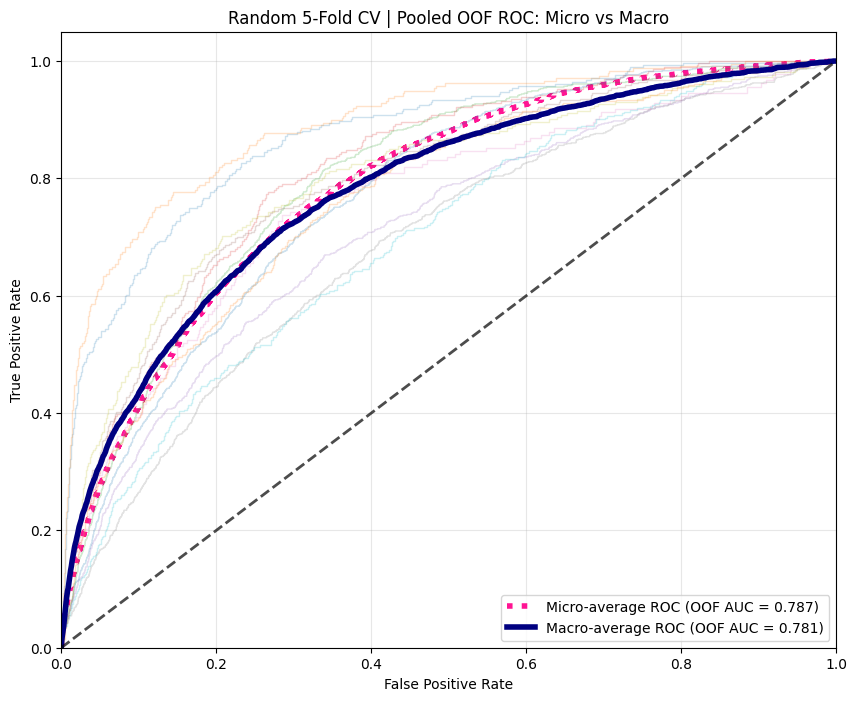

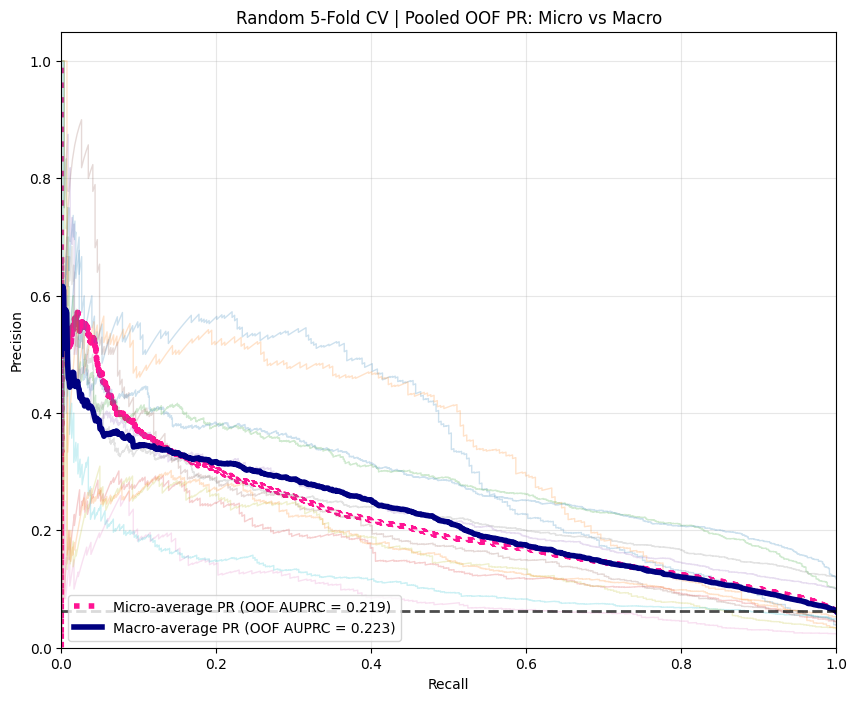

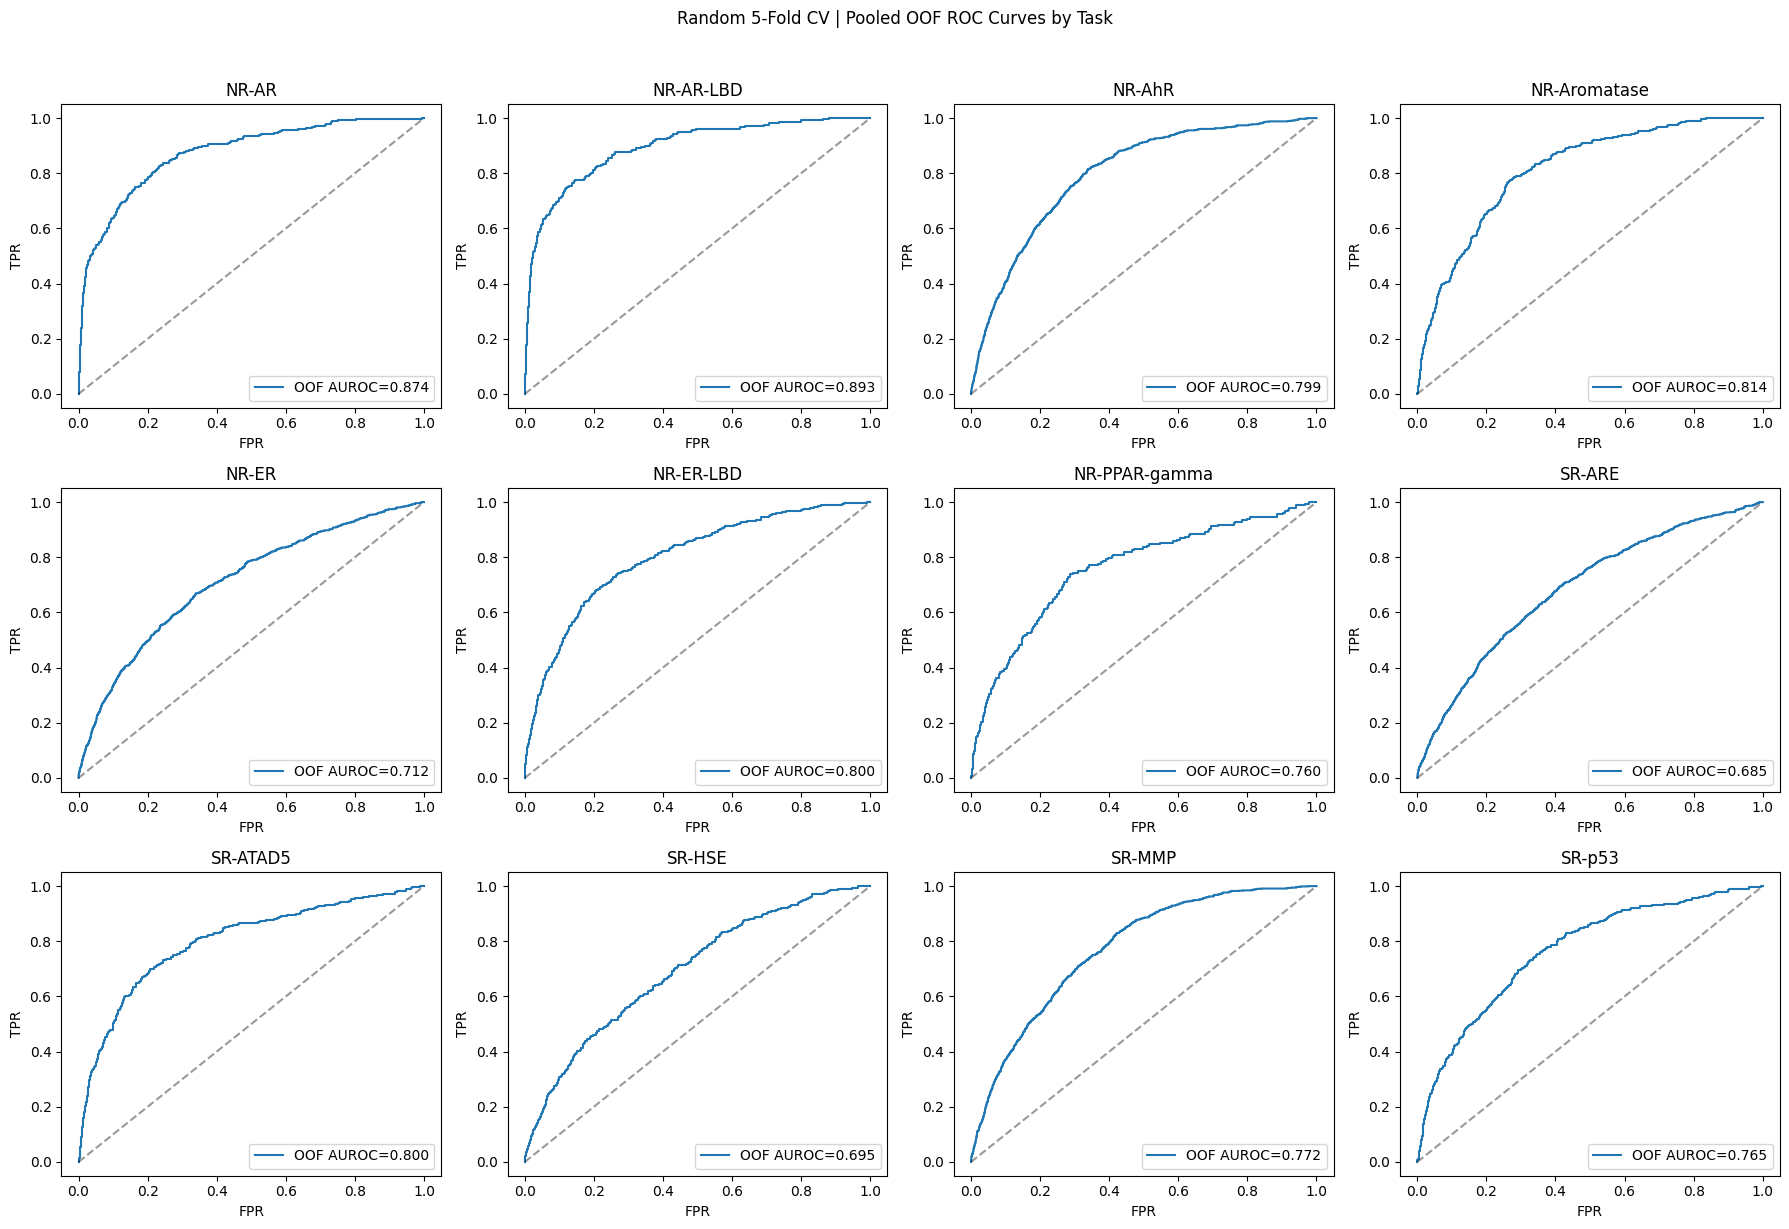

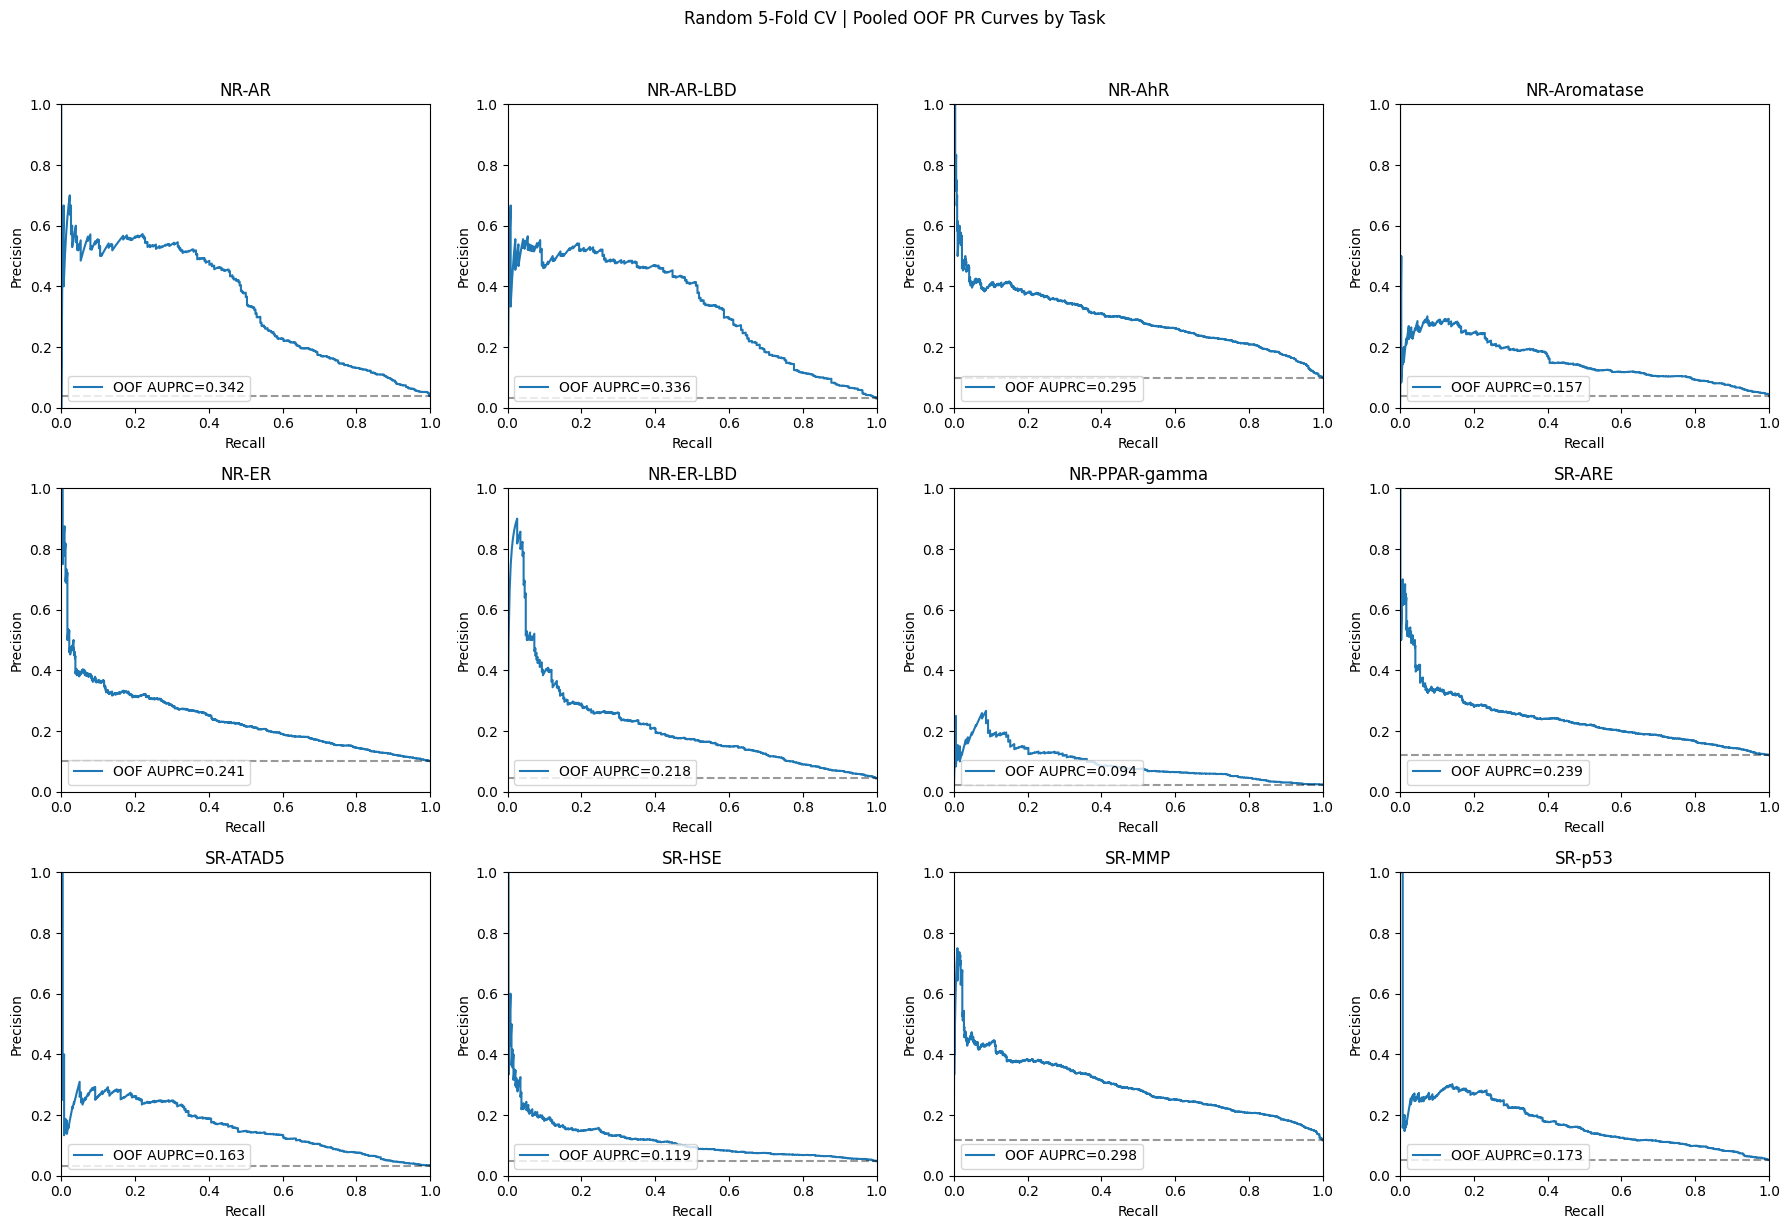


===== Multilabel Iterative Stratified 5-Fold CV =====
Fixed post-training recipe:
{'checkpoint_path': '/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase2_adaptive_best.pt', 'finetuning_scope': 'pred_head only', 'loss_name': 'focal', 'focal_gamma': 4.0, 'batch_size': 128, 'max_epochs': 50, 'patience': 8, 'head_lr': 0.0001, 'weight_decay': 0.0001, 'training_in_notebook': False}

Reporting convention:
- scalar metrics: mean/std across outer folds
- plots: pooled out-of-fold predictions from the outer held-out folds

Fold balance diagnostics:


,fold,n_train,n_inner_val,n_holdout,train_any_positive_rate,inner_val_any_positive_rate,holdout_any_positive_rate,train_mean_task_positive_rate,inner_val_mean_task_positive_rate,holdout_mean_task_positive_rate
0,1,5533,684,1555,0.363275,0.342105,0.383280,0.062037,0.064327,0.061951
1,2,5533,684,1555,0.367793,0.343567,0.366559,0.062007,0.063962,0.062219
2,3,5536,684,1552,0.367413,0.362573,0.359536,0.062214,0.062378,0.062178
3,4,5533,684,1555,0.371046,0.328947,0.361415,0.061977,0.064084,0.062272
4,5,5533,684,1555,0.367793,0.366959,0.356270,0.062112,0.062500,0.062487


Fold-level held-out metrics:


,fold,n_train,n_inner_val,n_holdout,best_epoch,best_inner_val_macro_auprc,best_inner_val_macro_auroc,macro_auroc,macro_auprc,micro_auroc,micro_auprc,loss
0,1,5533,684,1555,105,0.240245,0.764706,0.776018,0.211792,0.783523,0.203595,0.016051
1,2,5533,684,1555,105,0.244691,0.766432,0.801357,0.241655,0.801767,0.230549,0.015575
2,3,5536,684,1552,105,0.251891,0.796234,0.778143,0.246186,0.789380,0.226871,0.015333
3,4,5533,684,1555,105,0.270791,0.814469,0.769413,0.230911,0.778447,0.216969,0.015504
4,5,5533,684,1555,105,0.236957,0.785679,0.777613,0.237518,0.783920,0.224153,0.015222


Reportable CV summary (mean/std across folds) + pooled OOF reference:


,metric,cv_mean,cv_std,pooled_oof
0,macro_auroc,0.780509,0.012165,0.780660
1,macro_auprc,0.233612,0.013430,0.222823
2,micro_auroc,0.787407,0.008911,0.787460
3,micro_auprc,0.220427,0.010643,0.218908


Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):


,task,n_total,positive_rate,OOF_AUROC,OOF_AUPRC,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,NR-AR-LBD,7772,0.030494,0.892943,0.335510,0.893277,0.034106,0.357373,0.100254,0.737140,0.022140,0.170163,0.023119,0.094339,0.013950,0.877646,0.042088
1,NR-AR,7772,0.039115,0.874105,0.342035,0.873233,0.030795,0.358810,0.067853,0.708319,0.019881,0.190573,0.014160,0.106959,0.008486,0.874973,0.036029
2,NR-Aromatase,7772,0.038085,0.814022,0.157482,0.813944,0.033331,0.166417,0.039059,0.532811,0.010123,0.128937,0.005931,0.069395,0.003098,0.908588,0.059580
3,NR-ER-LBD,7772,0.044261,0.799851,0.218160,0.799159,0.019674,0.229291,0.018495,0.496786,0.009486,0.133413,0.007082,0.072217,0.003959,0.874753,0.032594
4,SR-ATAD5,7772,0.033582,0.799648,0.162686,0.799845,0.025374,0.179365,0.043784,0.510425,0.008513,0.106184,0.006480,0.056560,0.003442,0.866183,0.057991
5,NR-AhR,7772,0.098688,0.798906,0.294580,0.798527,0.020298,0.299901,0.049977,0.530627,0.008055,0.278206,0.004552,0.163996,0.002706,0.916586,0.020189
6,SR-MMP,7772,0.116701,0.771506,0.297969,0.771612,0.015206,0.301671,0.024386,0.505925,0.008910,0.301585,0.006267,0.180593,0.003974,0.913976,0.017837
7,SR-p53,7772,0.052625,0.765397,0.173363,0.765203,0.026650,0.180117,0.021876,0.453561,0.015623,0.148107,0.008600,0.080680,0.004770,0.902168,0.048102
8,NR-PPAR-gamma,7772,0.023546,0.759566,0.093773,0.759547,0.041839,0.109074,0.017419,0.492284,0.016228,0.072940,0.005834,0.038114,0.003100,0.846847,0.046050
9,NR-ER,7772,0.100875,0.711523,0.240631,0.711261,0.015249,0.244782,0.014475,0.387417,0.005965,0.223442,0.003493,0.128103,0.001951,0.873698,0.017948


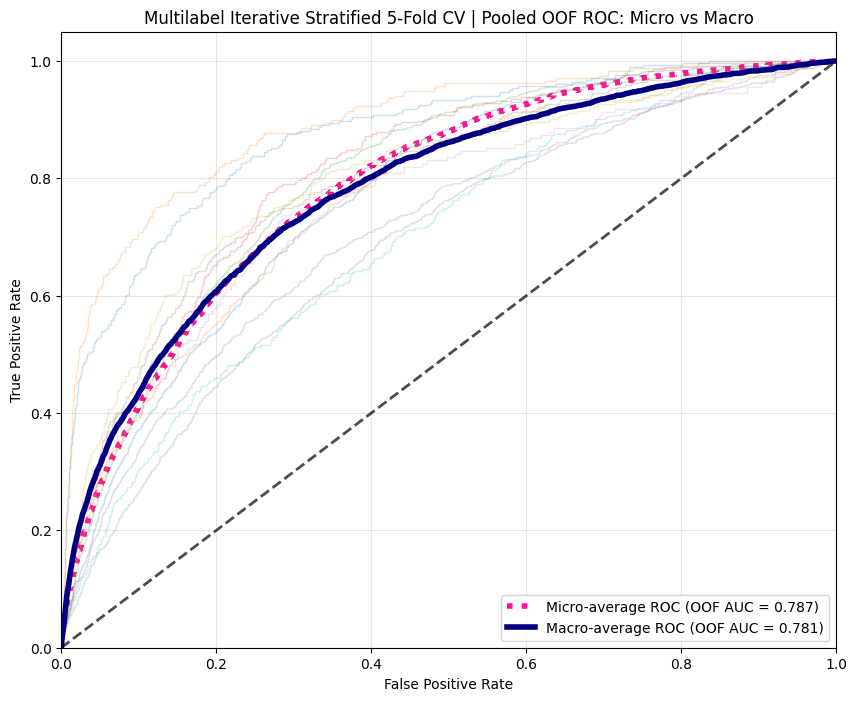

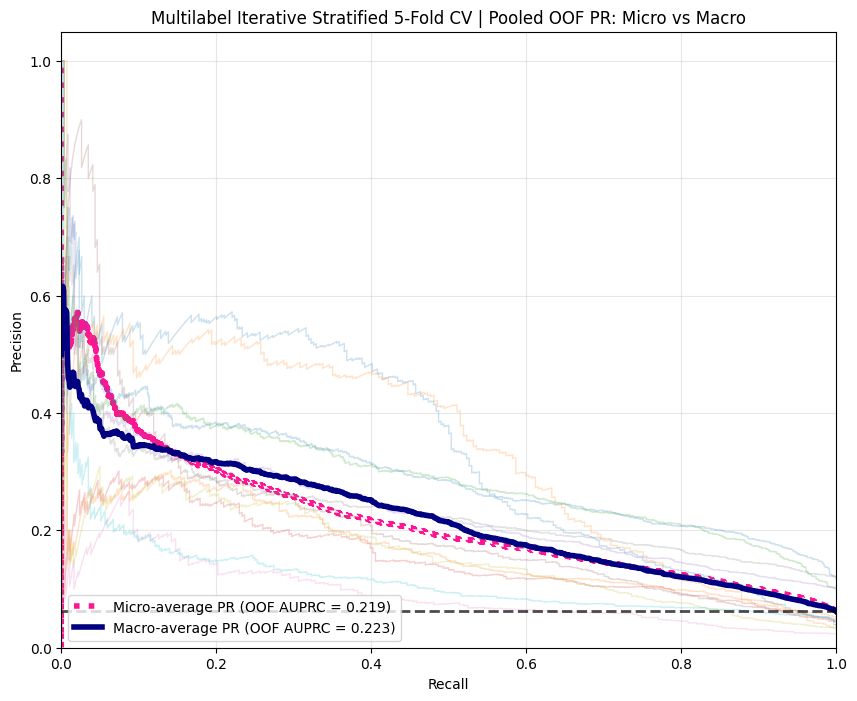

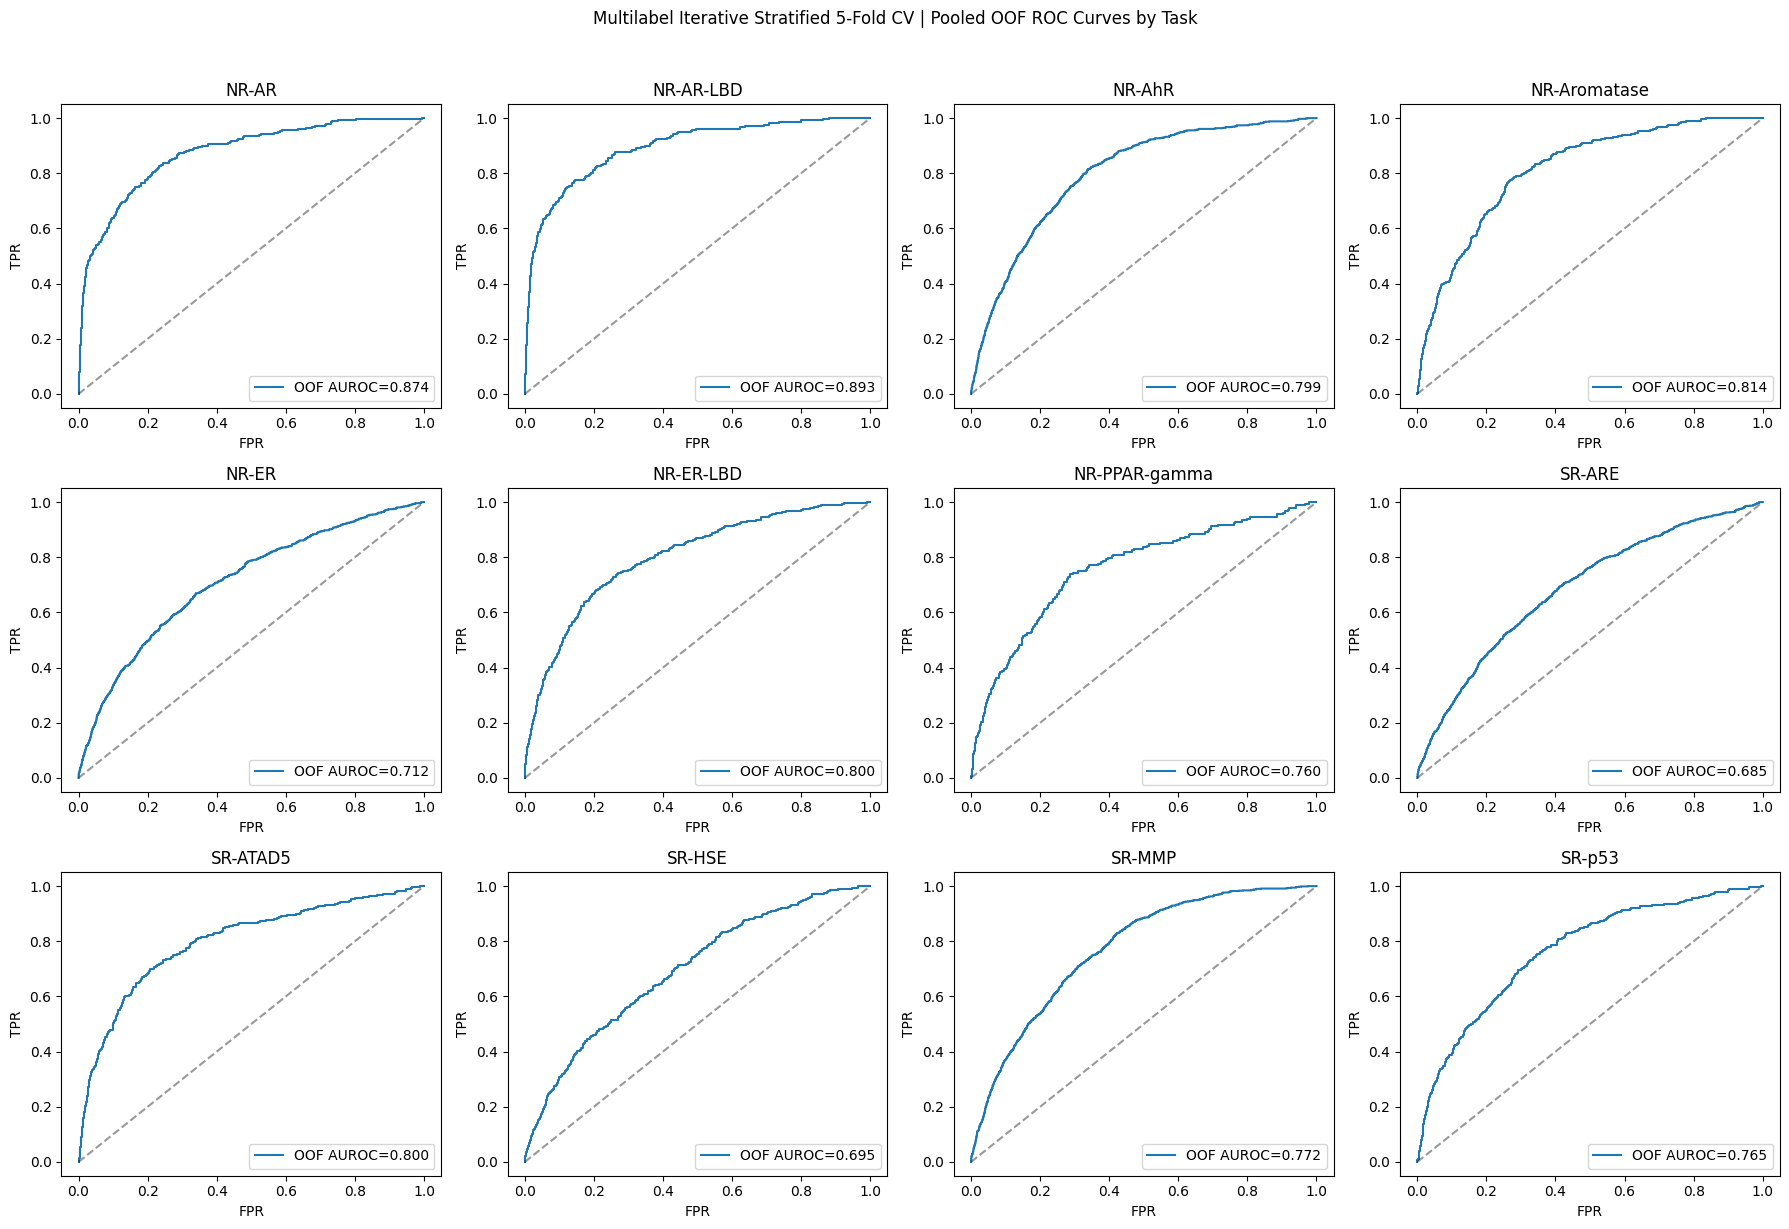

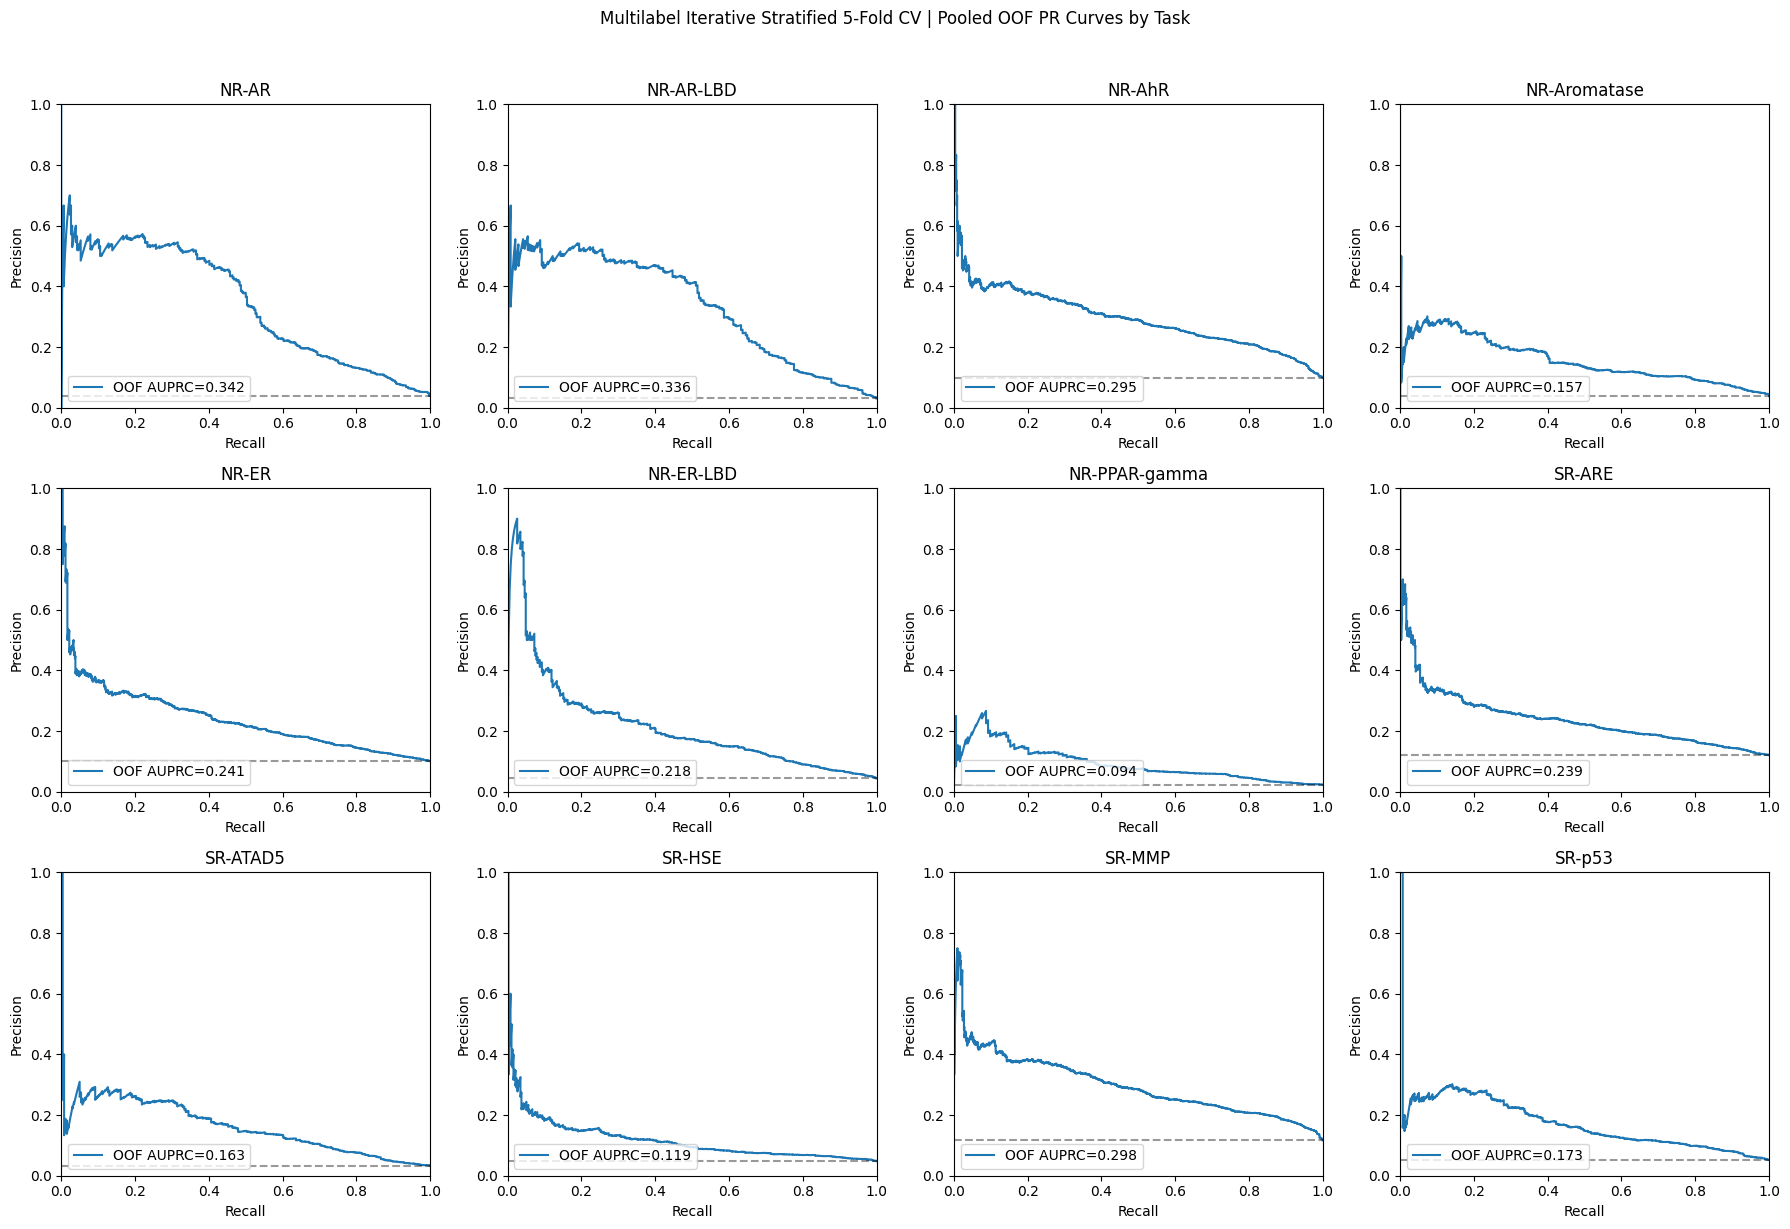

In [8]:
for strategy in STRATEGY_ORDER:
    if strategy not in experiment_results:
        continue

    result = experiment_results[strategy]

    print()
    print(f"===== {result['name']} =====")
    print("Fixed post-training recipe:")
    print(result["fixed_params"])
    print()
    print("Reporting convention:")
    print("- scalar metrics: mean/std across outer folds")
    print("- plots: pooled out-of-fold predictions from the outer held-out folds")

    print()
    print("Fold balance diagnostics:")
    display(result["fold_balance_df"])

    print("Fold-level held-out metrics:")
    display(result["fold_summary_df"])

    print("Reportable CV summary (mean/std across folds) + pooled OOF reference:")
    display(result["global_report_df"])

    print("Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):")
    display(result["task_summary_df"])

    plot_micro_macro_roc(result)
    plot_micro_macro_pr(result)
    plot_per_task_roc_grid(result, TOX21_TASKS)
    plot_per_task_pr_grid(result, TOX21_TASKS)

## 9. Final Comparison Snapshot

In [9]:
final_summary = comparison_df.copy()
final_summary

,strategy,strategy_label,mean_best_epoch,macro_auroc_cv_mean,macro_auroc_cv_std,macro_auroc_pooled_oof,macro_auprc_cv_mean,macro_auprc_cv_std,macro_auprc_pooled_oof,micro_auroc_cv_mean,micro_auroc_cv_std,micro_auroc_pooled_oof,micro_auprc_cv_mean,micro_auprc_cv_std,micro_auprc_pooled_oof
0,random,Random 5-Fold CV,105.0,0.780386,0.004401,0.78066,0.231272,0.02081,0.222823,0.787367,0.005123,0.78746,0.220390,0.020797,0.218908
1,multilabel_iterstrat,Multilabel Iterative Stratified 5-Fold CV,105.0,0.780509,0.012165,0.78066,0.233612,0.01343,0.222823,0.787407,0.008911,0.78746,0.220427,0.010643,0.218908
